In [2]:
import sys
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from typing import Optional


# ---------------------------------------------------------------------------
# 1. Загрузка матрицы винрейтов из Excel
# ---------------------------------------------------------------------------

def load_winrate_matrix(path: str, sheet: int | str = 0) -> tuple[list[str], np.ndarray]:
    """
    Читает Excel-файл и возвращает список агентов + матрицу винрейтов.

    Параметры
    ----------
    path  : путь к .xlsx / .xls файлу
    sheet : номер или имя листа (по умолчанию первый лист)

    Возвращает
    ----------
    agents : list[str]  — упорядоченный список имён агентов
    W      : ndarray (n, n), W[i, j] = winrate агента i против j (0–100),
             np.nan если данных нет.

    Примечание
    ----------
    Если задано W[i,j], но W[j,i] пустое — W[j,i] автоматически заполняется
    как 100 - W[i,j]. Если заданы оба — оставляем оба (возможна асимметрия
    из-за разного числа партий; compute_bayesian_elo усредняет их).
    """
    df = pd.read_excel(path, sheet_name=sheet, index_col=0, header=0)
    df.index   = df.index.astype(str).str.strip()
    df.columns = df.columns.astype(str).str.strip()

    # Объединяем всех агентов из строк и столбцов (сохраняем порядок)
    all_agents = list(dict.fromkeys(list(df.index) + list(df.columns)))
    n = len(all_agents)
    idx = {a: i for i, a in enumerate(all_agents)}

    W = np.full((n, n), np.nan)

    for row_agent in df.index:
        i = idx[row_agent]
        for col_agent in df.columns:
            j = idx[col_agent]
            val = df.loc[row_agent, col_agent]
            if pd.notna(val):
                W[i, j] = float(val)
                if np.isnan(W[j, i]):         # симметричное дополнение
                    W[j, i] = 100.0 - float(val)

    return all_agents, W


# ---------------------------------------------------------------------------
# 2. Байесовское Elo — MAP по модели Bradley-Terry
# ---------------------------------------------------------------------------

def compute_bayesian_elo(
    agents: list[str],
    W: np.ndarray,
    anchor_agent: Optional[str] = None,
    anchor_elo: float = 0.0,
    prior_sigma: float = 400.0,
) -> pd.DataFrame:
    """
    Вычисляет байесовское Elo для всех агентов.

    Модель
    ------
    P(i beats j) = sigmoid((elo_i - elo_j) / ELO_SCALE),  ELO_SCALE = 400/ln10

    Log-likelihood суммирует по всем известным парам:
        ℓ += score_i * log P(i>j) + score_j * log P(j>i)
    где score_i = W[i,j] / 100  (винрейт уже учитывает ничьи как 0.5).

    Prior: elo_k ~ N(0, prior_sigma²)  — L2-регуляризация, не даёт
    рейтингам уходить в бесконечность при малом числе партий.

    Якорь: если задан anchor_agent, его рейтинг жёстко фиксируется через
    очень сильный штраф (σ_anchor = 0.001 Elo).

    Параметры
    ----------
    agents       : список имён (порядок совпадает с осями W)
    W            : матрица винрейтов (n×n), значения 0–100, NaN = нет данных
    anchor_agent : имя агента-якоря (задаёт нулевую точку шкалы)
    anchor_elo   : Elo якоря (по умолчанию 0)
    prior_sigma  : σ гауссового prior в Elo-единицах (по умолчанию 400)

    Возвращает
    ----------
    pd.DataFrame  — колонки: agent, elo; строки отсортированы по убыванию Elo;
                    индекс = ранг (с 1).
    """
    n = len(agents)
    agent_idx = {a: i for i, a in enumerate(agents)}
    anchor_idx = agent_idx.get(anchor_agent) if anchor_agent else None
    ELO_SCALE = 400.0 / np.log(10.0)   # ≈ 173.7

    def neg_log_posterior(elo: np.ndarray) -> float:
        log_lik = 0.0
        for i in range(n):
            for j in range(i + 1, n):
                wr_ij = W[i, j]
                wr_ji = W[j, i]
                if np.isnan(wr_ij) and np.isnan(wr_ji):
                    continue
                # Усредняем оба направления если известны
                if not np.isnan(wr_ij) and not np.isnan(wr_ji):
                    score_i = (wr_ij / 100.0 + (100.0 - wr_ji) / 100.0) / 2.0
                elif not np.isnan(wr_ij):
                    score_i = wr_ij / 100.0
                else:
                    score_i = (100.0 - wr_ji) / 100.0

                score_j = 1.0 - score_i
                diff = (elo[i] - elo[j]) / ELO_SCALE
                log_p_i = -np.log1p(np.exp(-diff))   # log σ(diff)
                log_p_j = -np.log1p(np.exp(diff))    # log σ(-diff)
                log_lik += score_i * log_p_i + score_j * log_p_j

        # Гауссовый prior
        log_prior = -0.5 * np.sum((elo / prior_sigma) ** 2)

        # Якорь — жёсткий штраф
        anchor_pen = 0.0
        if anchor_idx is not None:
            anchor_pen = -0.5 * ((elo[anchor_idx] - anchor_elo) / 1e-3) ** 2

        return -(log_lik + log_prior + anchor_pen)

    result = minimize(
        neg_log_posterior,
        x0=np.zeros(n),
        method="L-BFGS-B",
        options={"maxiter": 2000, "ftol": 1e-12},
    )

    elo_values = result.x.copy()

    # Нормировка шкалы
    if anchor_idx is not None:
        elo_values += anchor_elo - elo_values[anchor_idx]
    else:
        elo_values -= elo_values.mean()   # центрируем по среднему

    df = pd.DataFrame({"agent": agents, "elo": np.round(elo_values, 1)})
    df = df.sort_values("elo", ascending=False).reset_index(drop=True)
    df.index += 1
    df.index.name = "rank"
    return df


# ---------------------------------------------------------------------------
# 3. Обёртка «всё в одном»
# ---------------------------------------------------------------------------

def elo_from_excel(
    path: str,
    sheet: int | str = 0,
    anchor_agent: Optional[str] = None,
    anchor_elo: float = 0.0,
    prior_sigma: float = 400.0,
) -> pd.DataFrame:
    """Полный пайплайн: Excel-файл → DataFrame с Elo-рейтингами."""
    agents, W = load_winrate_matrix(path, sheet)
    return compute_bayesian_elo(agents, W, anchor_agent, anchor_elo, prior_sigma)


# ---------------------------------------------------------------------------
# 5. Визуализация Elo-рейтингов (matplotlib)
# ---------------------------------------------------------------------------

def plot_elo_ratings(
    df: "pd.DataFrame",
    samples_per_version: float,
    ref_prefix: str = "ref_",
    agent_version_sep: str = "_",
    output_path: str = "elo_ratings.png",
    title: str = "",
):
    """
    Рисует scatter-график байесовского Elo (matplotlib).

    Параметры
    ----------
    df                  : DataFrame с колонками 'agent' и 'elo'
                          (результат compute_bayesian_elo / elo_from_excel)
    samples_per_version : сэмплов на одну версию агента (абс., напр. 150_000)
    ref_prefix          : префикс имён референсных агентов (напр. "ref_")
    agent_version_sep   : разделитель перед номером версии в имени агента.
                          Например, "_" → "agent_12" даёт версию 12.
                          X-позиция точки = версия × samples_per_version (M).
    output_path         : путь для сохранения PNG
    title               : заголовок графика

    Обозначения
    -----------
    ●  Синие кружки   — обучаемые агенты; X = накопленные сэмплы (M)
                        подпись над точкой = значение X в миллионах
    ▲  Зелёные треугольники — референсы; горизонтальные пунктиры
                        показывают их уровень по всей оси X
    """
    import matplotlib.pyplot as plt
    import json as _json

    df = df.reset_index(drop=True).copy()
    spv_M = samples_per_version / 1_000_000

    is_ref   = df["agent"].str.startswith(ref_prefix)
    train_df = df[~is_ref].copy()
    ref_df   = df[ is_ref].copy()

    def extract_version(name: str) -> float:
        parts = name.rsplit(agent_version_sep, 1)
        try:
            return float(parts[-1])
        except ValueError:
            return float("nan")

    train_df["version"] = train_df["agent"].apply(extract_version)
    train_df = train_df.sort_values("version").reset_index(drop=True)
    train_df["x"] = train_df["version"] * spv_M

    x_max = train_df["x"].max() if len(train_df) > 0 else spv_M
    x_ref = x_max * 1.08

    fig, ax = plt.subplots(figsize=(10, 5.5))

    # Горизонтальные пунктиры уровней референсов
    for _, row in ref_df.iterrows():
        ax.axhline(row["elo"], color="#28a050", linewidth=0.9,
                   linestyle="--", alpha=0.45, zorder=1)

    # Guide-линия между агентами
    if len(train_df) > 1:
        ax.plot(train_df["x"], train_df["elo"],
                color="#7aaae8", linewidth=1.2, linestyle=":",
                alpha=0.7, zorder=2)

    # Синие кружки — обучаемые агенты
    ax.scatter(train_df["x"], train_df["elo"],
               marker="o", s=80, color="#2266cc",
               edgecolors="white", linewidths=1.2, zorder=4, label="Нейросетевые")

    # Подписи X (сэмплы в M) над точками
    for i, row in train_df.iterrows():
        ax.annotate(
            f"v_{i * 25}",
            xy=(row["x"], row["elo"]),
            xytext=(0, 9), textcoords="offset points",
            ha="center", va="bottom", fontsize=8.5, color="#2255aa",
        )

    # Зелёные треугольники — референсы
    ax.scatter([x_ref] * len(ref_df), ref_df["elo"].tolist(),
               marker="^", s=90, color="#28a050",
               edgecolors="white", linewidths=1.2, zorder=4, label="Эвристические")

    for _, row in ref_df.iterrows():
        ax.annotate(
            row["agent"],
            xy=(x_ref, row["elo"]),
            xytext=(7, 0), textcoords="offset points",
            ha="left", va="center", fontsize=8.5, color="#1a6630",
        )

    ax.set_xlabel("Тренировочных сэмплов (M)", fontsize=12)
    ax.set_ylabel("Рейтинг Эло", fontsize=12)
    ax.set_title(title, pad=12)
    ax.grid(True, color="#e0e0e8", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    ax.set_xticks(train_df["x"].tolist())
    ax.set_xticklabels([f"{v:.2f}" for v in train_df["x"]], fontsize=9)
    ax.set_xlim(left=-spv_M * 0.5, right=x_ref + x_max * 0.20)
    ax.legend(loc="upper left", fontsize=10, framealpha=0.85, edgecolor="#cccccc")

    plt.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

    with open(output_path + ".meta.json", "w") as _f:
        _json.dump({
            "caption": "Bayesian Elo: agents (●) vs references (▲)",
            "description": (
                "X = cumulative training samples (M), derived from agent version number. "
                "Blue circles = trained agents, green triangles = fixed reference agents."
            ),
        }, _f)
    return fig


In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


def _save_df(df: pd.DataFrame, output_path: str | Path) -> pd.DataFrame:
    output_path = Path(output_path)
    if output_path.suffix.lower() == ".csv":
        df.to_csv(output_path, index=False)
    elif output_path.suffix.lower() in {".xlsx", ".xls"}:
        df.to_excel(output_path, index=False)
    else:
        raise ValueError("output_path must end with .csv, .xlsx, or .xls")
    return df


def _value_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c != "komi"]



def _perlin2d(
    rows: int,
    cols: int,
    scale_x: float = 24.0,
    scale_y: float = 8.0,
    seed: int = 42,
) -> np.ndarray:
    """Двумерный шум Перлина размером (rows, cols)."""
    rng = np.random.default_rng(seed)
    perm = rng.permutation(256).astype(np.uint8)
    perm = np.concatenate([perm, perm])  # повтор для wrap-around

    ys = np.arange(rows, dtype=float) / max(scale_y, 1e-6)
    xs = np.arange(cols, dtype=float) / max(scale_x, 1e-6)
    gx, gy = np.meshgrid(xs, ys)

    x0 = np.floor(gx).astype(int)
    y0 = np.floor(gy).astype(int)
    x1, y1 = x0 + 1, y0 + 1
    dx, dy = gx - x0, gy - y0
    fx, fy = _fade(dx), _fade(dy)

    def g(xi, yi):
        return _grad2d(perm[(perm[xi & 255] + yi) & 255].astype(int),
                       gx - xi, gy - yi)

    n00 = g(x0, y0)
    n10 = g(x1, y0)
    n01 = g(x0, y1)
    n11 = g(x1, y1)

    lx0 = n00 + fx * (n10 - n00)
    lx1 = n01 + fx * (n11 - n01)
    noise = lx0 + fy * (lx1 - lx0)

    std = np.std(noise)
    if std > 1e-8:
        noise /= std
    return noise



def _find_balance_line(df: pd.DataFrame) -> np.ndarray:
    vals = df[_value_cols(df)].to_numpy(dtype=float)
    komi = df["komi"].to_numpy(dtype=float)
    line = np.zeros(vals.shape[1], dtype=float)
    for j in range(vals.shape[1]):
        col = vals[:, j]
        idx = np.argsort(np.abs(col - 50.0))[0]
        line[j] = komi[idx]
    return line

def add_perlin_noise_near_line(
    df: pd.DataFrame,
    output_path: str | Path,
    amplitude: float = 7.0,
    band_sigma: float = 1.8,
    scale: float = 18.0,
    seed: int = 42,
    preserve_zero_komi: bool = True,
) -> pd.DataFrame:
    """
    Добавляет 1D-перлин-подобный шум вдоль линии баланса (где winrate≈50).

    Шум тем сильнее, чем ближе ячейка к линии. Для каждой версии j:
      - находим komi-линию баланса L[j] как значение komi с winrate ближе всего к 50;
      - генерируем плавный шум noise[j] вдоль оси версий;
      - для каждой строки i добавляем:
            delta[i,j] = amplitude * noise[j] * exp(-0.5 * ((komi_i - L[j])/band_sigma)^2)

    Все методы принимают DataFrame, возвращают DataFrame и перезаписывают файл.
    """
    out = df.copy()
    cols = _value_cols(out)
    vals = out[cols].to_numpy(dtype=float)
    komi = out["komi"].to_numpy(dtype=float)

    line = _find_balance_line(out)
    noise2d = _perlin2d(vals.shape[0], vals.shape[1], scale_x=scale, scale_y=max(scale/3, 2.0), seed=seed)

    for j in range(vals.shape[1]):
        dist = komi - line[j]
        w = np.exp(-0.5 * (dist / max(band_sigma, 1e-6)) ** 2)
        vals[:, j] = vals[:, j] + amplitude * noise2d[:, j] * w

    if preserve_zero_komi:
        zero_idx = np.where(np.isclose(komi, 0.0))[0]
        if len(zero_idx) > 0:
            z = zero_idx[0]
            vals[z, :] = np.clip(vals[z, :], 45.0, 55.0)

    vals = np.clip(vals, 0.0, 100.0)
    out[cols] = np.round(vals, 2)
    return _save_df(out, output_path)
def _fade(t: np.ndarray) -> np.ndarray:
    return 6*t**5 - 15*t**4 + 10*t**3
def _grad2d(h: np.ndarray, dx: np.ndarray, dy: np.ndarray) -> np.ndarray:
    h = h & 3
    u = np.where(h < 2, dx, dy)
    v = np.where(h < 2, dy, dx)
    return np.where(h & 1, -u, u) + np.where(h & 2, -v, v)


def draw_base_polyline(
    df: pd.DataFrame,
    output_path: str | Path,
    control_points: list[tuple[float, float]],
    segment_widths: list[float] | float,
    segment_sharpness: list[float] | float,
    low_value: float = 0.0,
    high_value: float = 100.0,
    preserve_zero_komi: bool = True,
) -> pd.DataFrame:
    """
    Рисует базовую ломаную линию от первой точки к последней и формирует
    heatmap-поверхность вокруг неё.

    control_points:
        список точек (x_rel, y_komi), где
        x_rel ∈ [0, 1] — относительное положение по оси версий,
        y_komi        — высота линии в координатах komi.

    Ломаная строится как цепочка отрезков между соседними точками.
    Для каждого отрезка можно задать:
        - segment_widths[s]   : ширину переходной зоны;
        - segment_sharpness[s]: резкость перехода.

    Для каждой колонки j строится положение линии y=line_y[j].
    Затем по вертикали формируется переход:

        value = low + (high-low) / (1 + exp((komi - line_y[j]) * alpha))

    где alpha зависит от width и sharpness сегмента.

    Интерпретация:
        - ниже линии значения стремятся к high_value;
        - выше линии значения стремятся к low_value;
        - около линии расположен переход 50%.

    Все методы принимают и возвращают DataFrame и перезаписывают файл.
    """
    out = df.copy()
    cols = _value_cols(out)
    komi = out["komi"].to_numpy(dtype=float)
    n_cols = len(cols)

    if len(control_points) < 2:
        raise ValueError("control_points must contain at least 2 points")

    pts = [(float(x), float(y)) for x, y in control_points]
    pts = sorted(pts, key=lambda p: p[0])
    n_segments = len(pts) - 1

    if isinstance(segment_widths, (int, float)):
        widths = [float(segment_widths)] * n_segments
    else:
        widths = [float(x) for x in segment_widths]

    if isinstance(segment_sharpness, (int, float)):
        sharpness = [float(segment_sharpness)] * n_segments
    else:
        sharpness = [float(x) for x in segment_sharpness]

    if len(widths) != n_segments or len(sharpness) != n_segments:
        raise ValueError("segment_widths and segment_sharpness must match number of segments")

    xs = np.linspace(0.0, 1.0, n_cols)
    vals = np.zeros((len(komi), n_cols), dtype=float)

    for j, x in enumerate(xs):
        if x <= pts[0][0]:
            seg = 0
            x0, y0 = pts[0]
            x1, y1 = pts[1]
        elif x >= pts[-1][0]:
            seg = n_segments - 1
            x0, y0 = pts[-2]
            x1, y1 = pts[-1]
        else:
            seg = None
            for s in range(n_segments):
                x0, y0 = pts[s]
                x1, y1 = pts[s + 1]
                if x0 <= x <= x1:
                    seg = s
                    break
            if seg is None:
                seg = n_segments - 1
                x0, y0 = pts[-2]
                x1, y1 = pts[-1]

        t = 0.0 if abs(x1 - x0) < 1e-9 else (x - x0) / (x1 - x0)
        line_y = y0 + t * (y1 - y0)

        width = max(widths[seg], 1e-6)
        sharp = max(sharpness[seg], 1e-6)

        # alpha: узкий width и большая sharpness => более резкий переход
        alpha = sharp / width
        col = low_value + (high_value - low_value) / (1.0 + np.exp((komi - line_y) * alpha))
        vals[:, j] = col

    if preserve_zero_komi:
        zero_idx = np.where(np.isclose(komi, 0.0))[0]
        if len(zero_idx) > 0:
            vals[zero_idx[0], :] = np.clip(vals[zero_idx[0], :], 45.0, 55.0)

    vals = np.clip(vals, low_value, high_value)
    out[cols] = np.round(vals, 2)
    return _save_df(out, output_path)


def create_empty_heatmap_table(
    output_path: str | Path,
    komi_start: float = -14.5,
    komi_end: float = 14.5,
    komi_step: float = 0.5,
    n_versions: int = 251,
    fill_value: float = 50.0,
) -> pd.DataFrame:
    """
    Создаёт пустую таблицу нужной размерности для heatmap.

    Структура:
        - первый столбец: komi
        - остальные столбцы: v_1, v_2, ..., v_n_versions

    По умолчанию создаёт таблицу 59 x 251 по условиям задачи:
        komi: -14.5 .. 14.5 с шагом 0.5
        versions: 1 .. 251

    Все ячейки заполняются fill_value (по умолчанию 50.0), чтобы таблицу
    можно было сразу модифицировать последующими методами.

    Все методы принимают и возвращают DataFrame и перезаписывают файл.
    """
    komi_values = np.round(np.arange(komi_start, komi_end + komi_step / 2.0, komi_step), 1)
    data = {"komi": komi_values}
    for v in range(1, n_versions + 1):
        data[f"v_{v}"] = np.full(len(komi_values), float(fill_value))

    df = pd.DataFrame(data)
    return _save_df(df, output_path)



def add_global_perlin_noise(
    df: pd.DataFrame,
    output_path: str | Path,
    amplitude: float = 2.0,
    scale_x: float = 28.0,
    scale_y: float = 10.0,
    seed: int = 42,
    preserve_zero_komi: bool = True,
) -> pd.DataFrame:
    """
    Добавляет слабый глобальный 2D шум Перлина ко всей heatmap.

    Используется для лёгкого «оживления» всей таблицы после построения базовой формы.
    Шум равномерно накладывается на все ячейки, без привязки к линии баланса.

    Все методы принимают и возвращают DataFrame и перезаписывают файл.
    """
    out = df.copy()
    cols = _value_cols(out)
    vals = out[cols].to_numpy(dtype=float)
    komi = out["komi"].to_numpy(dtype=float)

    noise2d = _perlin2d(vals.shape[0], vals.shape[1], scale_x=scale_x, scale_y=scale_y, seed=seed)
    vals = vals + amplitude * noise2d

    if preserve_zero_komi:
        zero_idx = np.where(np.isclose(komi, 0.0))[0]
        if len(zero_idx) > 0:
            vals[zero_idx[0], :] = np.clip(vals[zero_idx[0], :], 45.0, 55.0)

    vals = np.clip(vals, 0.0, 100.0)
    out[cols] = np.round(vals, 2)
    return _save_df(out, output_path)


def smooth_heatmap(
    df: pd.DataFrame,
    output_path: str | Path,
    sigma_y: float = 1.0,
    sigma_x: float = 1.5,
    preserve_zero_komi: bool = True,
) -> pd.DataFrame:
    """
    Применяет сглаживающий/размывающий фильтр ко всей heatmap.

    Используется гауссово размытие:
        - sigma_y управляет сглаживанием по оси komi
        - sigma_x управляет сглаживанием по оси версий

    Все методы принимают и возвращают DataFrame и перезаписывают файл.
    """
    out = df.copy()
    cols = _value_cols(out)
    vals = out[cols].to_numpy(dtype=float)
    komi = out["komi"].to_numpy(dtype=float)

    smoothed = gaussian_filter(vals, sigma=(sigma_y, sigma_x), mode='nearest')

    if preserve_zero_komi:
        zero_idx = np.where(np.isclose(komi, 0.0))[0]
        if len(zero_idx) > 0:
            smoothed[zero_idx[0], :] = np.clip(smoothed[zero_idx[0], :], 45.0, 55.0)

    smoothed = np.clip(smoothed, 0.0, 100.0)
    out[cols] = np.round(smoothed, 2)
    return _save_df(out, output_path)

In [4]:
path1 = ".\\test1\\final_shit\\black_winrate_heatmap_table1.csv"
path2 = ".\\test1\\final_shit\\black_winrate_heatmap_table2.csv"
path3 = ".\\test1\\final_shit\\black_winrate_heatmap_table3.csv"
path4 = ".\\test1\\final_shit\\black_winrate_heatmap_table4.csv"
path5 = ".\\test1\\final_shit\\black_winrate_heatmap_table5.csv"
path6 = ".\\test1\\final_shit\\black_winrate_heatmap_table6.csv"
path7 = ".\\test1\\final_shit\\black_winrate_heatmap_table7.csv"
path8 = ".\\test1\\final_shit\\black_winrate_heatmap_table8.csv"
path9 = ".\\test1\\final_shit\\black_winrate_heatmap_table9.csv"
path10 = ".\\test1\\final_shit\\black_winrate_heatmap_table10.csv"

In [5]:
df = create_empty_heatmap_table(output_path=path1)

df2 = draw_base_polyline(
    df=df, 
    output_path=path2, 
    control_points=[(0,0), (5/251, 1), (15/251, 2), (30/251, 3), (50/251, 4), (100/251, 5), (251/251, 4.6)], 
    segment_widths=[1.2,1.1,1,0.9,0.8,0.7],
    segment_sharpness=[.1,.2,.5,.6,.8,1.2], preserve_zero_komi=False)



df3 = add_perlin_noise_near_line(df2, path3, amplitude=15, scale=50, band_sigma=0.5, preserve_zero_komi=False, seed=898)

df4 = smooth_heatmap(df3, path4, sigma_x=4, sigma_y=0, preserve_zero_komi=True)

df5 = add_global_perlin_noise(df4, path5, scale_x=10, scale_y=5, amplitude=1, seed=456, preserve_zero_komi=False)
df6 = add_global_perlin_noise(df5, path6, scale_x=8, scale_y=2, amplitude=1, seed=123, preserve_zero_komi=False)
df7 = add_global_perlin_noise(df6, path7, scale_x=1.5, scale_y=1.5, amplitude=1, seed=1523, preserve_zero_komi=False)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors


def make_winrate_cmap(center=0.5, half_width=0.2, sharpness=1):
    """
    Colormap на базе RdYlGn с узкой нейтральной зоной.

    center     — центр нейтральной зоны (0.5 = 50% винрейт)
    half_width — полуширина жёлтой зоны в единицах [0,1]
                 0.05 → жёлтый виден только в диапазоне 45-55%
    sharpness  — крутизна перехода; 6-8 хорошо, 12+ почти ступенька
    """
    base = plt.cm.RdYlGn
    x = np.linspace(0, 1, 512)

    shifted = (x - center) / half_width
    warped  = 0.5 + 0.5 * np.tanh(shifted * sharpness)

    colors = base(warped)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "RdYlGn_sharp", list(zip(x, colors)), N=512
    )
    cmap.set_bad(color="#aaaaaa")   # серый для NaN
    return cmap


def plot_black_winrate_heatmap(csv_path, output_path="black_winrate_heatmap_v2.png"):
    df = pd.read_csv(csv_path)
    komi = df["komi"]
    data = df.drop(columns=["komi"])

    cmap = make_winrate_cmap()
    cmap.set_bad(color="#aaaaaa")   # серый для NaN

    nan_mask = data.isna()


    plt.figure(figsize=(16, 8))
    ax = sns.heatmap(
        data,
        cmap=cmap,
        mask=nan_mask,
        vmin=0,
        vmax=100,
        cbar_kws={"label": "Доля побед черных (%)"}
    )

    # X-только по ключевым версиям (каждые 25)
    x_ticks = list(range(0, data.shape[1], 25))
    ax.set_xticks([x + 0.5 for x in x_ticks])
    ax.set_xticklabels([str(x + 1) for x in x_ticks], rotation=0)

    # Y — несколько коми через шаг
    y_ticks = list(range(0, len(komi), 4))
    ax.set_yticks([y + 0.5 for y in y_ticks])
    ax.set_yticklabels([f"{komi.iloc[y]:.1f}" for y in y_ticks], rotation=0)

    ax.set_xlabel("Версия модели")
    ax.set_ylabel("Коми")
    ax.set_title("")

    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()

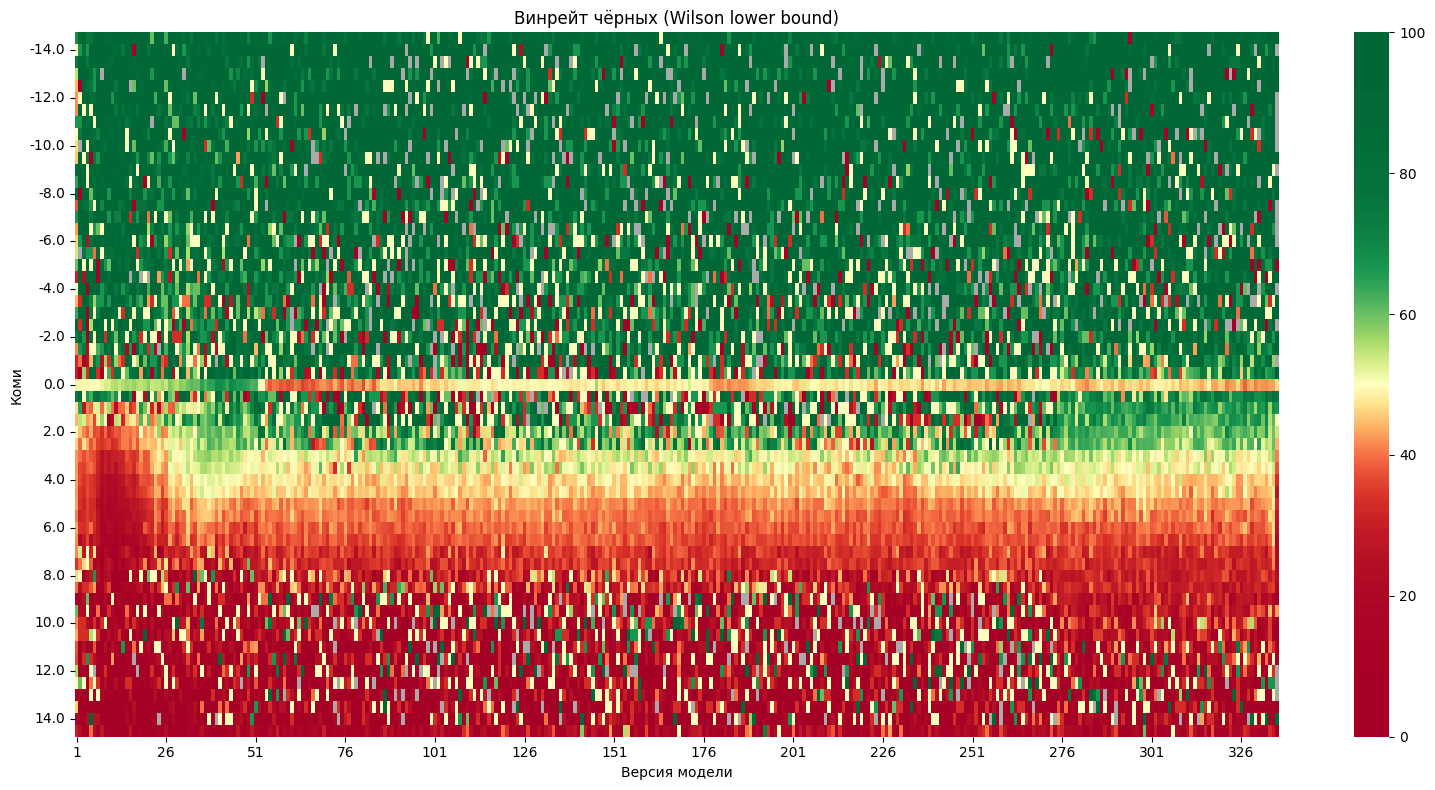

Saved: .\test1\final_shit\heatmap_winrate.png


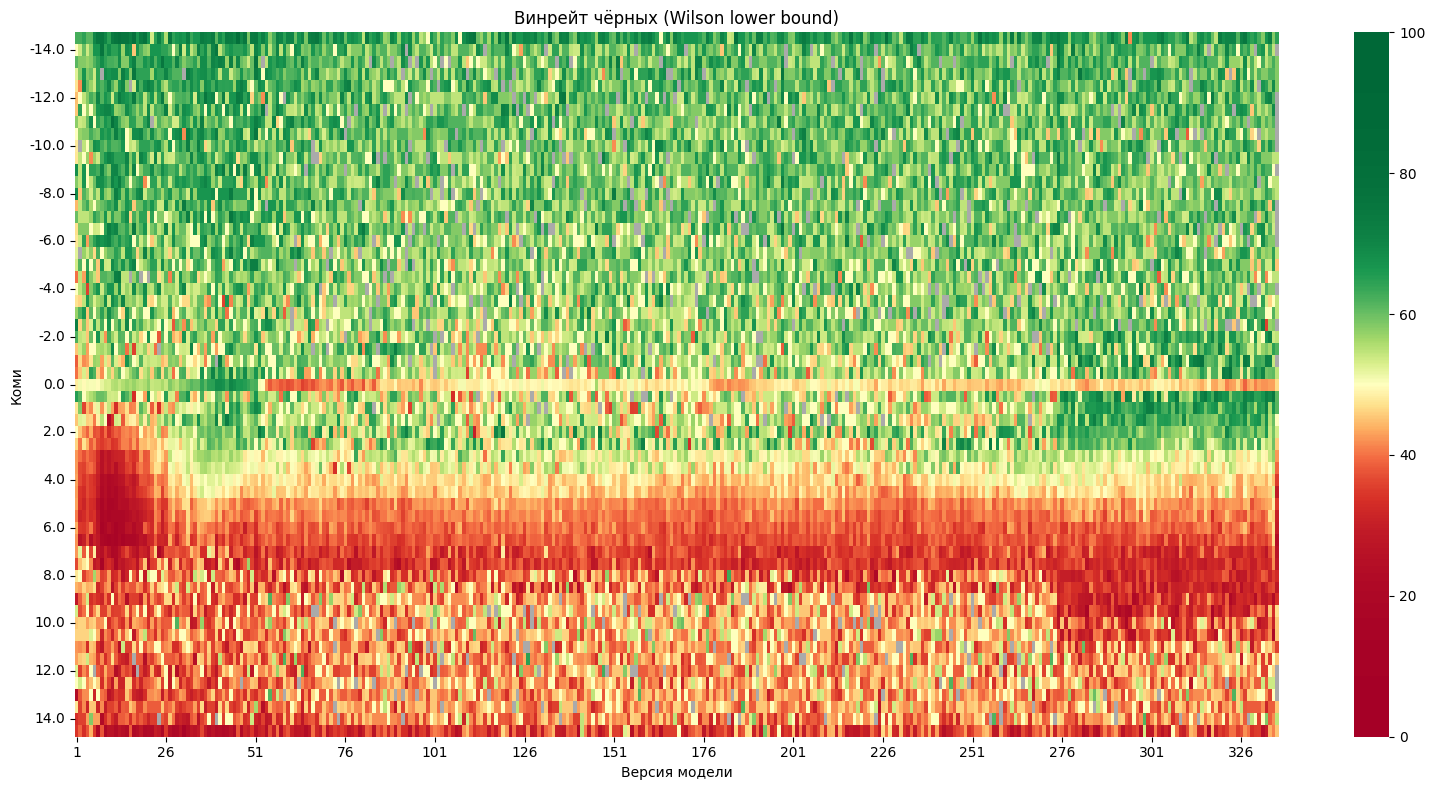

Saved: .\test1\final_shit\heatmap_winrate.png


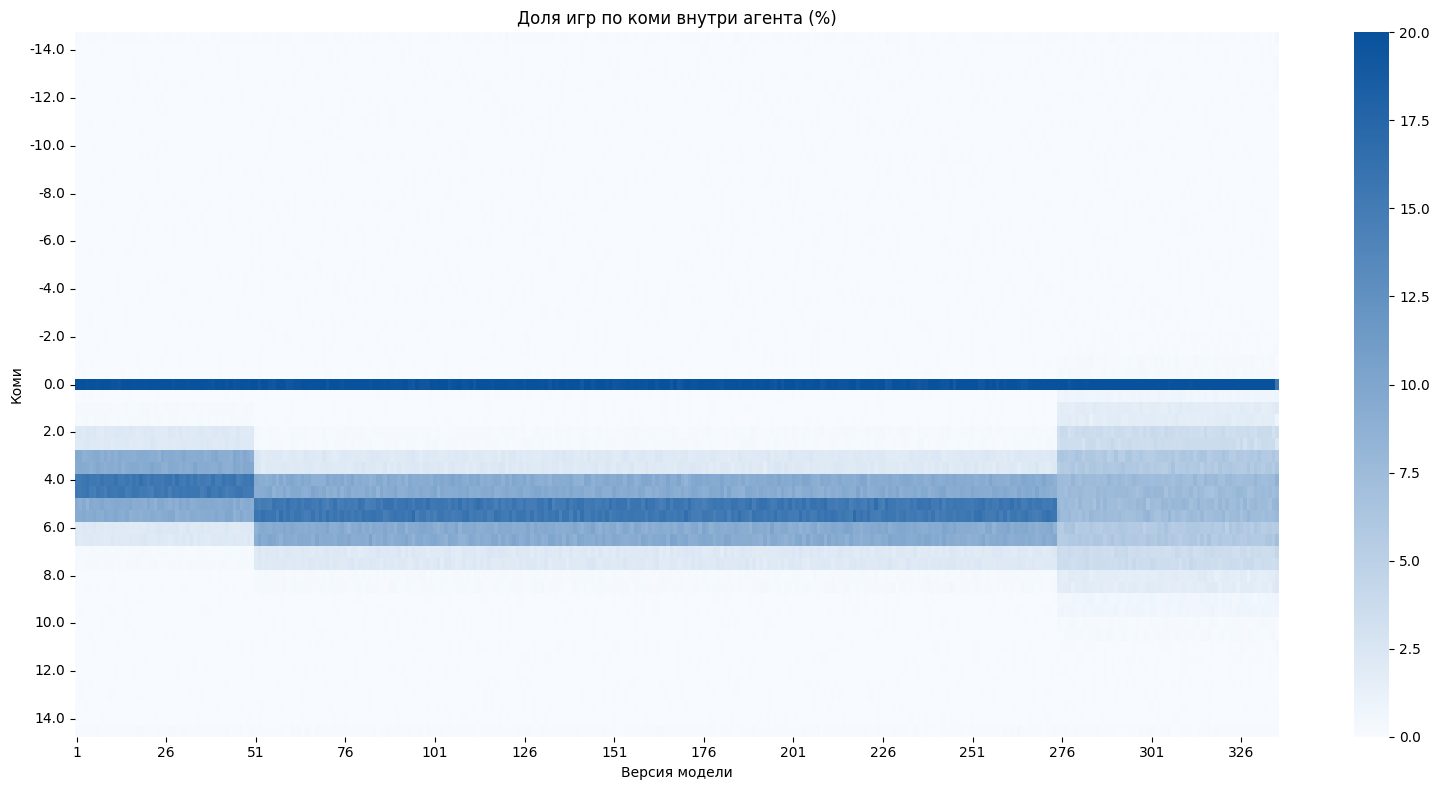

Saved: .\test1\final_shit\heatmap_pct_games.png


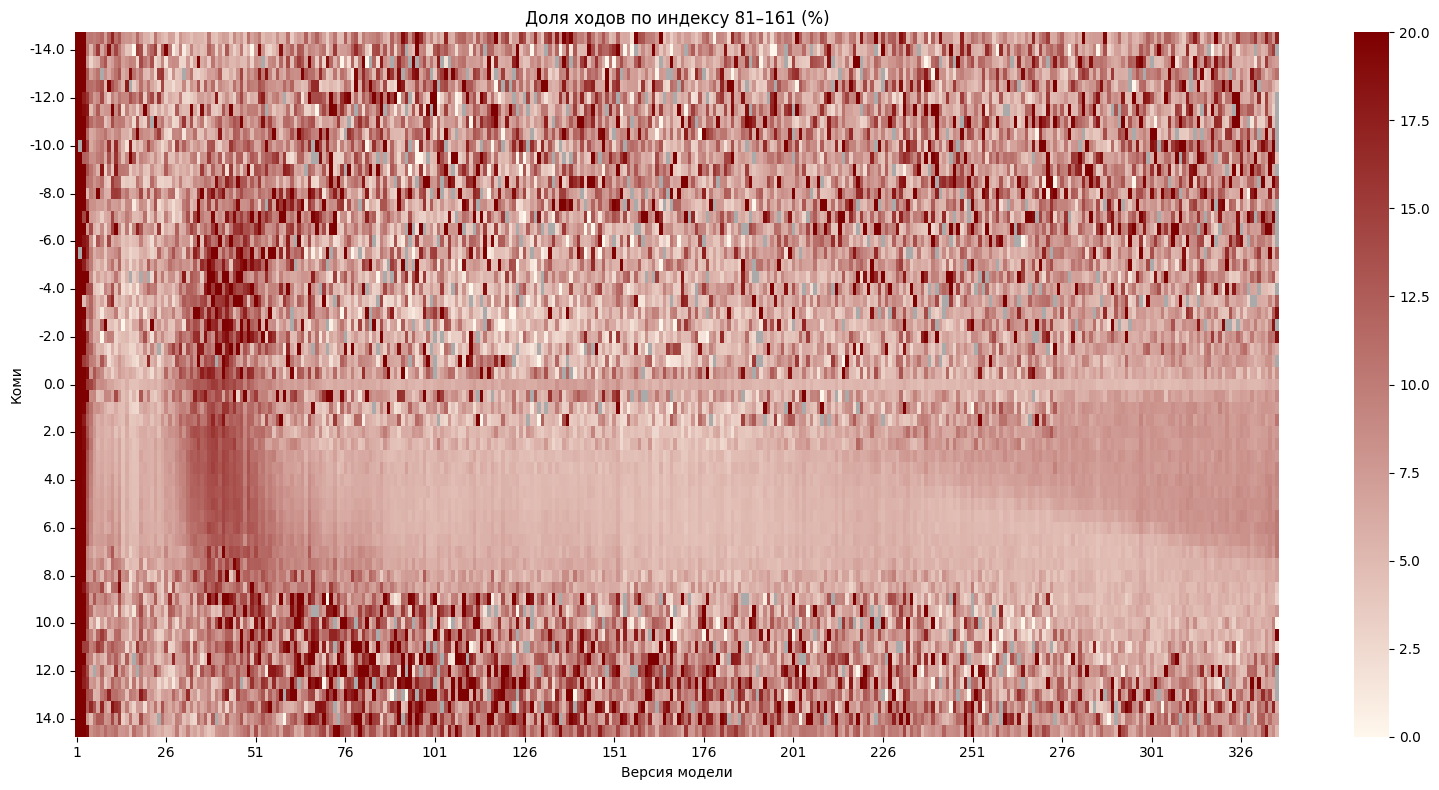

Saved: .\test1\final_shit\heatmap_pct_moves.png


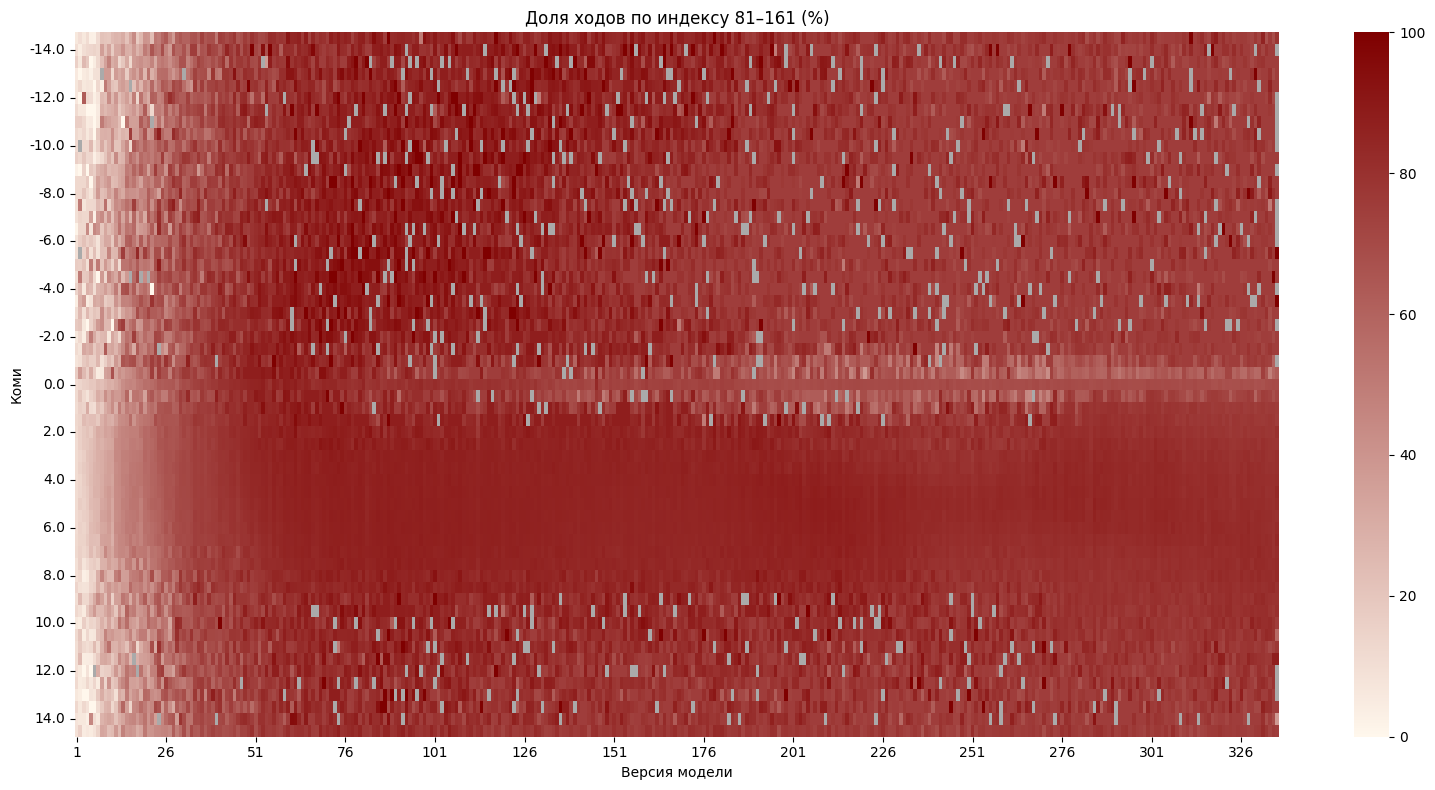

Saved: .\test1\final_shit\heatmap_pct_moves.png


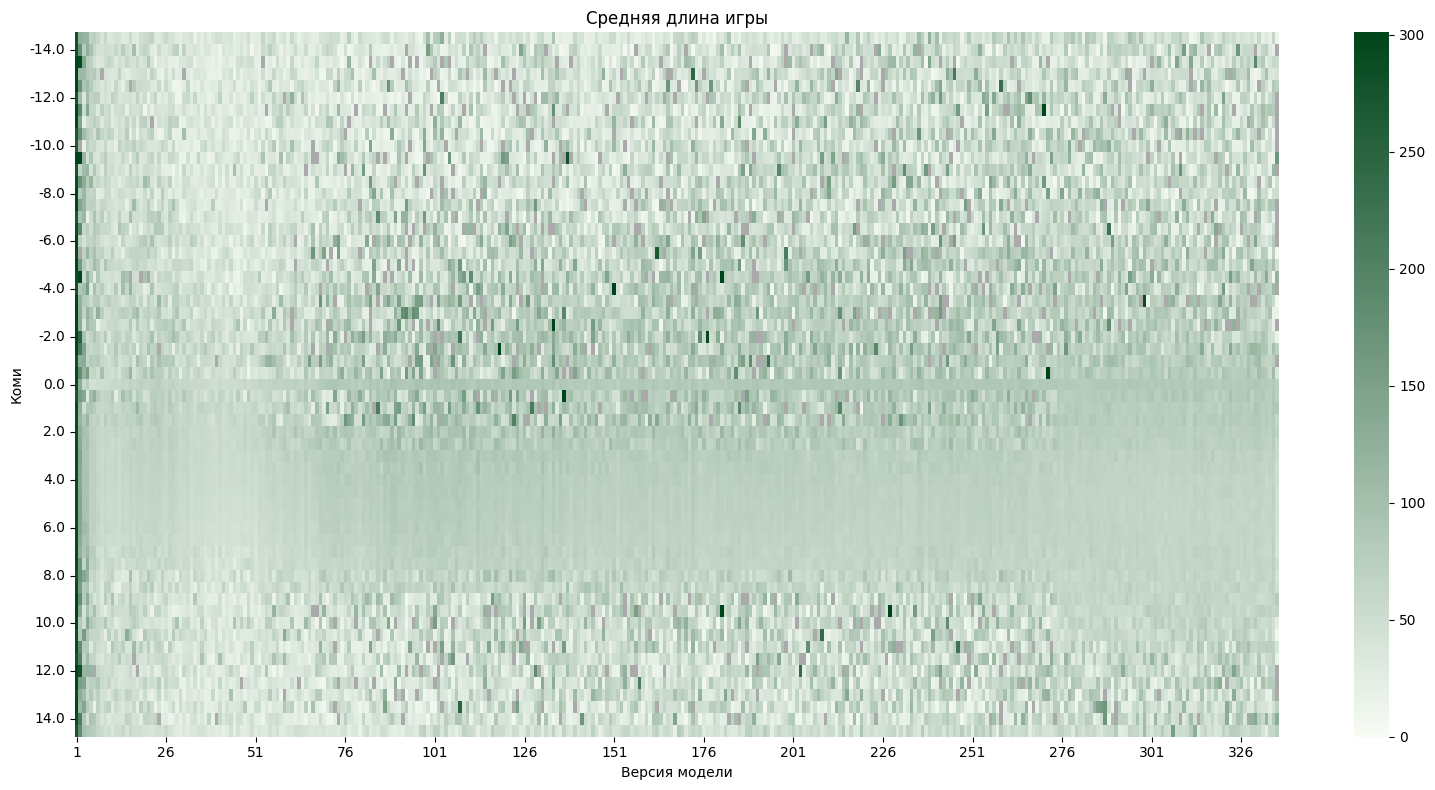

Saved: .\test1\final_shit\heatmap_avg_length.png


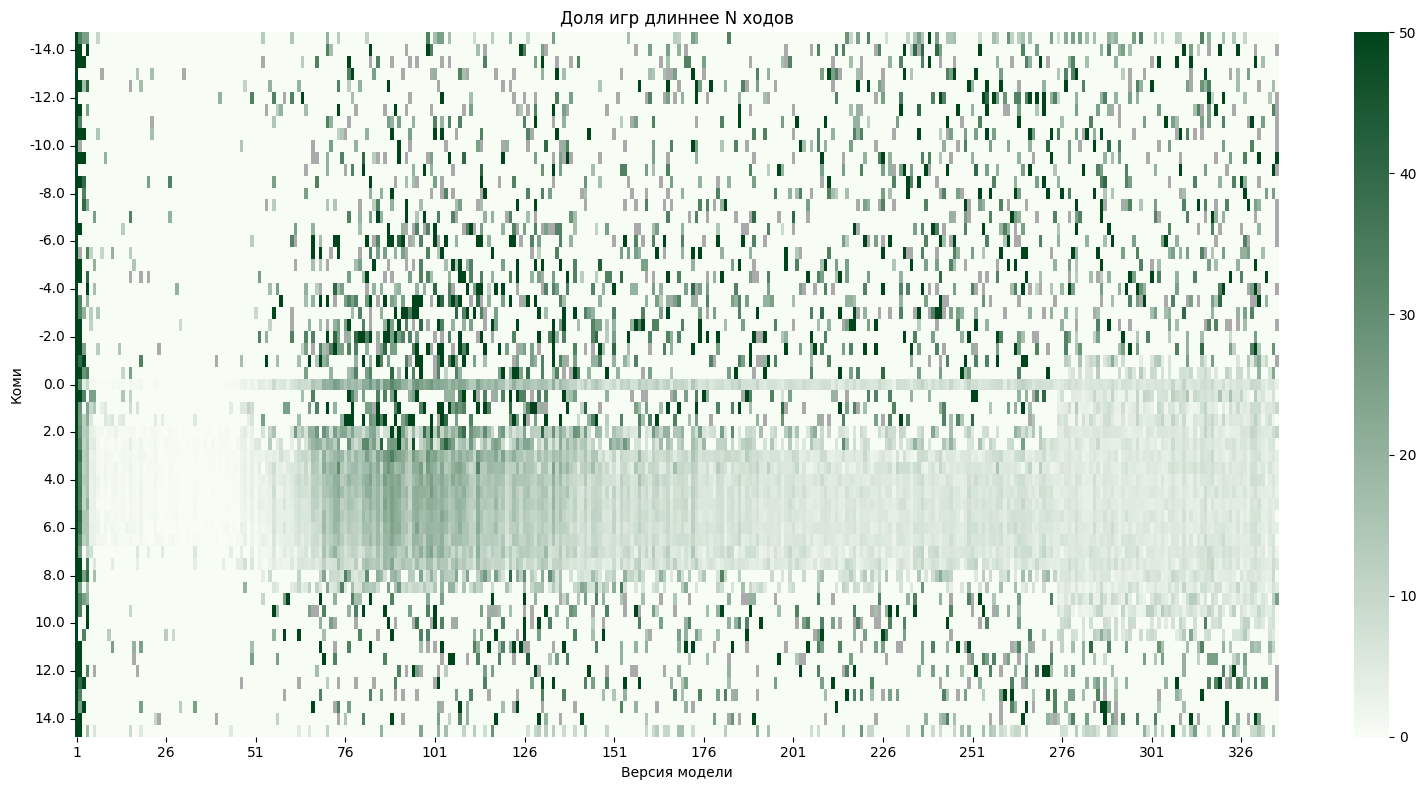

Saved: .\test1\final_shit\heatmap_avg_length.png


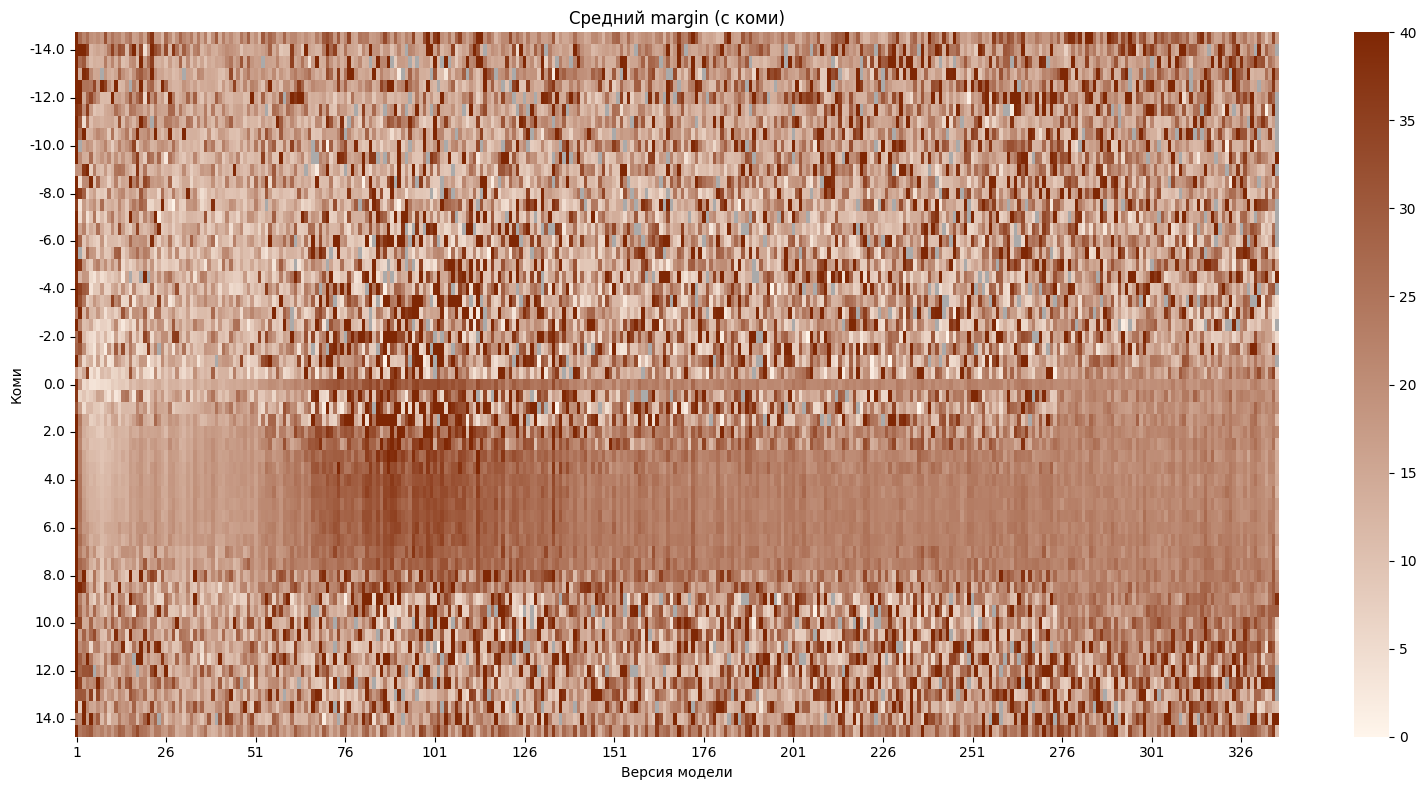

Saved: .\test1\final_shit\heatmap_avg_margin.png


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors


def make_winrate_cmap(center=0.5, half_width=0.2, sharpness=1):
    base = plt.cm.RdYlGn
    x = np.linspace(0, 1, 512)
    shifted = (x - center) / half_width
    warped  = 0.5 + 0.5 * np.tanh(shifted * sharpness)
    colors = base(warped)
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "RdYlGn_sharp", list(zip(x, colors)), N=512
    )
    cmap.set_bad(color="#aaaaaa")
    return cmap


def make_linear_cmap(color_low="#f7fbff", color_high="#08306b", nan_color="#aaaaaa"):
    """Простой линейный градиент между двумя цветами."""
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "linear_custom", [color_low, color_high], N=512
    )
    cmap.set_bad(color=nan_color)
    return cmap


def plot_heatmap(
    csv_path,
    output_path,
    vmin,
    vmax,
    cmap,
    cbar_label="",
    nan_as_zero=False,       # True → NaN заменяется 0 перед рисованием
    nan_color="#aaaaaa",     # цвет NaN-ячеек (серый по умолчанию)
    title="",
):
    df = pd.read_csv(csv_path)
    komi = df["komi"]
    data = df.drop(columns=["komi"]).astype(float)

    # Обновляем nan_color у переданного cmap
    cmap.set_bad(color=nan_color)

    if nan_as_zero:
        # NaN → 0, маска не нужна — рисуем без серого
        data_plot = data.fillna(0.0)
        nan_mask  = pd.DataFrame(False, index=data.index, columns=data.columns)
    else:
        data_plot = data
        nan_mask  = data.isna()

    plt.figure(figsize=(16, 8))
    ax = sns.heatmap(
        data_plot,
        cmap=cmap,
        mask=nan_mask,
        vmin=vmin,
        vmax=vmax,
        cbar_kws={"label": cbar_label},
    )

    x_ticks = list(range(0, data.shape[1], 25))
    ax.set_xticks([x + 0.5 for x in x_ticks])
    ax.set_xticklabels([str(x + 1) for x in x_ticks], rotation=0)


    step = 4
    komi_arr = komi.values
    
    # Индекс строки с komi == 0 (с допуском на float)
    zero_idx = int(np.argmin(np.abs(komi_arr - 0.0)))
    
    # Тики: все индексы в диапазоне [0, len), кратные step относительно zero_idx
    y_ticks = [i for i in range(len(komi_arr))
               if (i - zero_idx) % step == 0]
    
    ax.set_yticks([y + 0.5 for y in y_ticks])
    ax.set_yticklabels([f"{komi_arr[y]:.1f}" for y in y_ticks], rotation=0)

    ax.set_xlabel("Версия модели")
    ax.set_ylabel("Коми")
    ax.set_title(title)

    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {output_path}")


BASE = ".\\test1\\final_shit\\"

# 1. Винрейт — RdYlGn с резкой нейтральной зоной, NaN → серый
plot_heatmap(
    csv_path   = BASE + "winrate_black_raw.csv",
    output_path= BASE + "heatmap_winrate.png",
    vmin=0, vmax=100,
    cmap       = make_winrate_cmap(center=0.5, half_width=0.15, sharpness=1),
    cbar_label = "",#Доля побед чёрных (%)
    nan_as_zero= False,
    nan_color  = "#aaaaaa",
    title      = "Винрейт чёрных (Wilson lower bound)",
)
# 1. Винрейт — RdYlGn с резкой нейтральной зоной, NaN → серый
plot_heatmap(
    csv_path   = BASE + "winrate_black_bayes.csv",
    output_path= BASE + "heatmap_winrate.png",
    vmin=0, vmax=100,
    cmap       = make_winrate_cmap(center=0.5, half_width=0.15, sharpness=1),
    cbar_label = "",#Доля побед чёрных (%)
    nan_as_zero= False,
    nan_color  = "#aaaaaa",
    title      = "Винрейт чёрных (Wilson lower bound)",
)

# 2. Процент игр по коми — линейный 0→50, NaN → 0
plot_heatmap(
    csv_path   = BASE + "pct_games_by_komi.csv",
    output_path= BASE + "heatmap_pct_games.png",
    vmin=0, vmax=20,
    cmap       = make_linear_cmap("#f7fbff", "#08519c"),
    cbar_label = "",#% игр агента при данном коми
    nan_as_zero= True,        # нет игр = 0%, не серый
    title      = "Доля игр по коми внутри агента (%)",
)

# 3. % ходов с move_flat 81–161 — линейный 0→10, NaN → серый
plot_heatmap(
    csv_path   = BASE + "pct_moves_81_161.csv",
    output_path= BASE + "heatmap_pct_moves.png",
    vmin=0, vmax=20,
    cmap       = make_linear_cmap("#fff7ec", "#7f0000"),
    cbar_label = "",#% ходов с move_flat ∈ [81, 161]
    nan_as_zero= False,
    nan_color  = "#aaaaaa",
    title      = "Доля ходов по индексу 81–161 (%)",
)

# 3. % ходов в центр
plot_heatmap(
    csv_path   = BASE + "pct_opening_board_moves_center_3x3.csv",
    output_path= BASE + "heatmap_pct_moves.png",
    vmin=0, vmax=100,
    cmap       = make_linear_cmap("#fff7ec", "#7f0000"),
    cbar_label = "",#% ходов с move_flat ∈ [81, 161]
    nan_as_zero= False,
    nan_color  = "#aaaaaa",
    title      = "Доля ходов по индексу 81–161 (%)",
)

# 4. Средняя длина игры — линейный 0→301, NaN → серый
plot_heatmap(
    csv_path   = BASE + "avg_game_length.csv",
    output_path= BASE + "heatmap_avg_length.png",
    vmin=0, vmax=301,
    cmap       = make_linear_cmap("#f7fcf5", "#00441b"),
    cbar_label = "", #Средняя длина игры (ходов)
    nan_as_zero= False,
    nan_color  = "#aaaaaa",
    title      = "Средняя длина игры",
)
# 4. Колво партий длиннее 100 ходов
plot_heatmap(
    csv_path   = BASE + "pct_games_gt_150.csv",
    output_path= BASE + "heatmap_avg_length.png",
    vmin=0, vmax=50,
    cmap       = make_linear_cmap("#f7fcf5", "#00441b"),
    cbar_label = "", #Средняя длина игры (ходов)
    nan_as_zero= False,
    nan_color  = "#aaaaaa",
    title      = "Доля игр длиннее N ходов",
)

# 5. Маржин — линейный 0→20, NaN → серый
plot_heatmap(
    csv_path   = BASE + "avg_margin.csv",
    output_path= BASE + "heatmap_avg_margin.png",
    vmin=0, vmax=40,
    cmap       = make_linear_cmap("#fff5eb", "#7f2704"),
    cbar_label = "",#Средняя разница по очкам
    nan_as_zero= False,
    nan_color  = "#aaaaaa",
    title      = "Средний margin (с коми)",
)

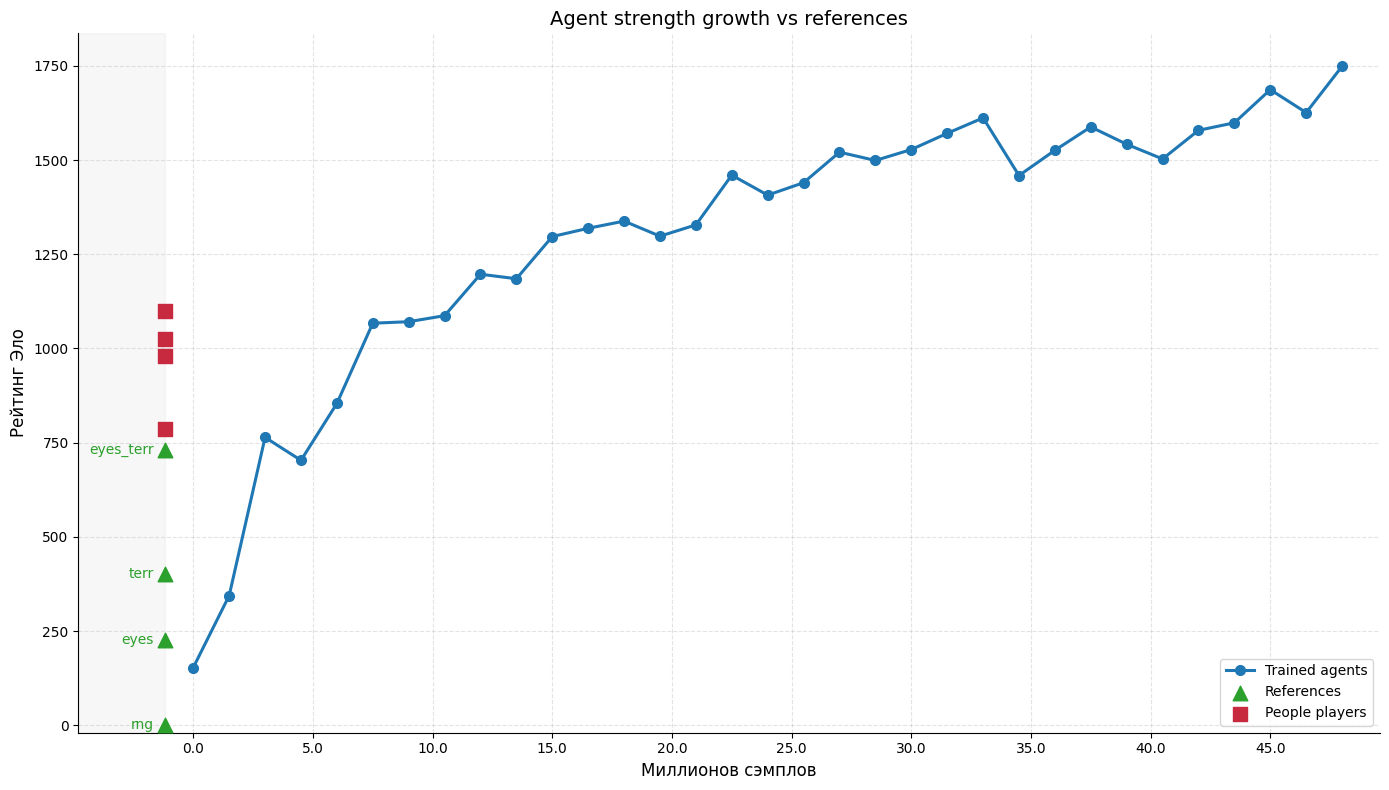

In [63]:
from matplotlib.ticker import FuncFormatter

def plot_bayeselo_with_references(
    agent_points,
    reference_points,
    people_players,
    samples_per_version_step_millions,
    title="Рейтинг Эло",
    figsize=(14, 8),
    annotate_agents=False,
    annotate_refs=True,
    agent_color="#1f77b4",
    ref_color="#2ca02c",
    people_color="#c72a3f"
):
    """
    agent_points: list of tuples (version, elo)
        example: [(1, -1147), (11, -956), (21, -536), ..., (321, 449)]

    reference_points: list of tuples (name, elo)
        example: [("Random", -1300), ("Heuristic", -200), ("Expert", 500)]

    samples_per_version_step_millions: float
        how many millions of samples correspond to one version step of 10
        example: if between v10 and v20 you have 15 million samples, pass 15.0

    Notes:
    - X for agents is cumulative samples:
        x(version) = ((version - min_version) / 10) * samples_per_version_step_millions
    - Y is shifted so that global minimum among agents and refs becomes 0
    """

    if not agent_points:
        raise ValueError("agent_points must not be empty")

    agent_points = sorted(agent_points, key=lambda x: x[0])

    versions = np.array([v for v, _ in agent_points], dtype=float)
    agent_elos_raw = np.array([e for _, e in agent_points], dtype=float)

    ref_names = [name for name, _ in reference_points]
    ref_elos_raw = np.array([e for _, e in reference_points], dtype=float) if reference_points else np.array([])

    people_elos_raw = np.array([e for _, e in people_players], dtype=float) if people_players else np.array([])
    
    global_min_elo = min(
        np.min(agent_elos_raw),
        np.min(ref_elos_raw) if len(ref_elos_raw) > 0 else np.inf
    )

    shift = -global_min_elo + 20
    agent_elos = agent_elos_raw + shift
    ref_elos = ref_elos_raw + shift if len(ref_elos_raw) > 0 else np.array([])
    
    people_elos = people_elos_raw + shift if len(ref_elos_raw) > 0 else np.array([])

    min_version = versions.min()

    x_agents = ((versions - min_version) / 10.0) * samples_per_version_step_millions

    max_x = x_agents.max() if len(x_agents) > 0 else 1.0

    ref_x = max_x * 0.075 if max_x > 0 else 0.5
    start_gap = max_x * 0.10 if max_x > 0 else 1.0

    x_agents = x_agents + start_gap

    x_min = 0.0
    x_max = x_agents.max() * 1.03

    fig, ax = plt.subplots(figsize=figsize)

    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x - start_gap:.1f}"))
    #ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{int(round(y - 20))}"))

    x_step = 5.0    # или какой тебе нужен шаг по X
    y0 = 20
    y_step = 250
    y_top = max(agent_elos)
    y_ticks_rel = np.arange(0, y_top - y0 + y_step, y_step)   # 0, 100, 200, ...
    y_ticks_pos = y0 + y_ticks_rel                            # 20, 120, 220, ...
    ax.set_yticks(y_ticks_pos, labels=[f"{int(t)}" for t in y_ticks_rel])

    x_ticks = np.arange(start_gap, x_max + x_step, x_step)
    

    ax.set_xticks(x_ticks)

    
    ax.plot(
        x_agents,
        agent_elos,
        color=agent_color,
        marker="o",
        markersize=7,
        linewidth=2.2,
        label="Trained agents",
        zorder=3
    )

    if len(reference_points) > 0:
        ax.scatter(
            np.full_like(ref_elos, ref_x, dtype=float),
            ref_elos,
            color=ref_color,
            marker="^",
            s=110,
            label="References",
            zorder=4
        )

    if len(people_players) > 0:
        ax.scatter(
            np.full_like(people_elos, ref_x, dtype=float),
            people_elos,
            color=people_color,
            marker="s",
            s=110,
            label="People players",
            zorder=4
        )


    if annotate_agents:
        for x, y, v in zip(x_agents, agent_elos, versions.astype(int)):
            ax.annotate(
                f"v_{v}",
                (x, y),
                textcoords="offset points",
                xytext=(5, 6),
                fontsize=9,
                color=agent_color
            )

    if annotate_refs and len(reference_points) > 0:
        for name, y in zip(ref_names, ref_elos):
            ax.annotate(
                name,
                (ref_x, y),
                textcoords="offset points",
                xytext=(-8, 0),
                ha="right",
                va="center",
                fontsize=10,
                color=ref_color
            )

    if len(reference_points) > 0:
        ax.axvspan(0, start_gap * 0.75, color="gray", alpha=0.06, zorder=0)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(bottom=0)

    ax.set_xlabel("Миллионов сэмплов", fontsize=12)
    ax.set_ylabel("Рейтинг Эло", fontsize=12)
    ax.set_title(title, fontsize=14)

    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend()

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


# ===== EXAMPLE DATA =====

agent_points = [
    (1, -1147),
    (11, -956),
    (21, -536),
    (31, -597),
    (41, -446),
    (51, -233),
    (61, -229),
    (71, -213),
    (81, -103),
    (91, -115),
    (101, -3),
    (111, 19),
    (121, 38),
    (131, -2),
    (141, 28),
    (151, 160),
    (161, 107),
    (171, 140),
    (181, 221),
    (191, 199),
    (201, 228),
    (211, 271),
    (221, 312),
    (231, 159),
    (241, 226),
    (251, 288),
    (261, 242),
    (271, 203),
    (281, 279),
    (291, 299),
    (301, 387),
    (311, 326),
    (321, 449),
]

reference_points = [
    ("rng", -1300),
    ("eyes", -1075),
    ("terr", -900),
    ("eyes_terr", -570),
]

people_players = [
    ("1", -200),
    ("2", -275),
    ("3", -320),
    ("4", -515),
]

plot_bayeselo_with_references(
    agent_points=agent_points,
    reference_points=reference_points,
    people_players=people_players,
    samples_per_version_step_millions=1.5,
    title="Agent strength growth vs references"
)

In [9]:
import json
import random
from pathlib import Path

FIELDS = ["policy", "opp_policy", "value", "terr", "score"]

def load_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

def save_jsonl(path, rows):
    with open(path, "w", encoding="utf-8") as f:
        for r in rows:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")

def upsample_with_jitter(rows, n_between=5, jitter_frac=0.10):
    if len(rows) < 2:
        return rows

    out = []
    current_step = rows[0]["step"]
    out.append({**rows[0], "step": current_step})

    for i in range(len(rows) - 1):
        a, b = rows[i], rows[i + 1]
        step_a, step_b = a["step"], b["step"]
        base_delta_step = step_b - step_a

        # разности по всем полям
        deltas = {k: b[k] - a[k] for k in FIELDS}

        # 5 промежуточных точек
        for j in range(1, n_between + 1):
            t = j / (n_between + 1)  # 1/6, 2/6, …, 5/6
            # jitter: множитель 0.9–1.1 на дельту
            multipliers = {
                k: random.uniform(1 - jitter_frac, 1 + jitter_frac)
                for k in FIELDS
            }
            interp = {
                k: a[k] + deltas[k] * t * multipliers[k]
                for k in FIELDS
            }

            current_step += base_delta_step / (n_between + 1)
            row = {"step": current_step}
            row.update(interp)
            out.append(row)

        # конечная точка B с шагом, дошедшим до step_b
        current_step += base_delta_step / (n_between + 1)
        out.append({**b, "step": current_step})

        for i, row in enumerate(out, start=1):
            row["step"] = i
    return out


src = ".\\training_meta\\training_meta_1.jsonl"
dst = ".\\training_meta\\meta_expanded.jsonl"

rows = load_jsonl(src)
#up_rows = upsample_with_jitter(rows, n_between=5, jitter_frac=0.10)
save_jsonl(dst, rows)

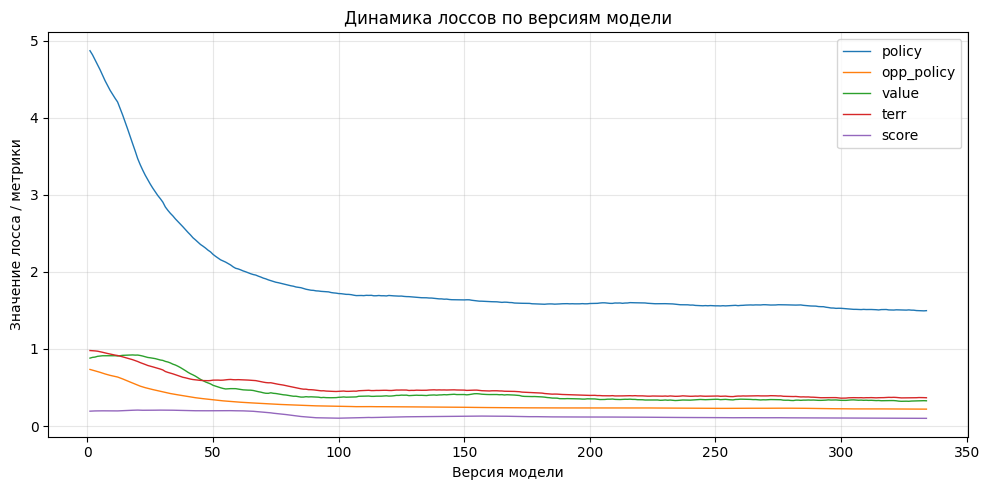

In [10]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def load_jsonl(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    return pd.read_json(path, lines=True)


def plot_all_losses(
    jsonl_path: str | Path,
    output_path: str | Path = "all_losses.png",
    step_key: str = "step",
    loss_keys=("policy", "opp_policy", "value", "terr", "score"),
):
    df = load_jsonl(jsonl_path)

    # Оставим только те ключи, которые реально есть в файле
    loss_keys = [k for k in loss_keys if k in df.columns]

    # На случай дробных step после апсемплинга сгруппируем по округлённой версии
    df["version"] = df[step_key].round().astype(int)
    grouped = df.groupby("version")[list(loss_keys)].mean().reset_index()

    plt.figure(figsize=(10, 5))

    for key in loss_keys:
        plt.plot(grouped["version"], grouped[key], label=key, linewidth=1)

    plt.xlabel("Версия модели")
    plt.ylabel("Значение лосса / метрики")
    plt.title("Динамика лоссов по версиям модели")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=180)
    plt.show()



plot_all_losses(dst, "all_losses.png")


In [9]:
import json
from typing import Any, Dict, Optional


def result_for_black_to_pgn_result(result_for_black: float) -> str:
    if result_for_black == 1.0:
        return "0-1"
    elif result_for_black == -1.0:
        return "1-0"
    return "1/2-1/2"


def get_nested_value(data: Dict[str, Any], key_path: str, default: Any = None) -> Any:
    cur = data
    for key in key_path.split("."):
        if not isinstance(cur, dict) or key not in cur:
            return default
        cur = cur[key]
    return cur


def append_rule_value_to_agent_name(
    agent_name: str,
    rules: Dict[str, Any],
    rule_key: Optional[str] = None,
    label: Optional[str] = None,
) -> str:
    if not rule_key:
        return agent_name

    value = get_nested_value(rules, rule_key, None)
    if value is None:
        return agent_name

    suffix = label or rule_key
    return f"{agent_name}_{suffix}={value}"


def build_pgn_entry_compact(
    rec: Dict[str, Any],
    rule_key: str = "deep_depth",
    rule_label: str = "dd",
    movetext: str = "1. e4 e5",
) -> str:
    # СОХРАНЯЕМ ТВОЮ ИСХОДНУЮ ЛОГИКУ МАППИНГА 1:1
    white = append_rule_value_to_agent_name(
        rec["agent_black"],
        rec.get("rules_black", {}),
        rule_key=rule_key,
        label=rule_label,
    )
    black = append_rule_value_to_agent_name(
        rec["agent_white"],
        rec.get("rules_white", {}),
        rule_key=rule_key,
        label=rule_label,
    )
    result = result_for_black_to_pgn_result(rec["result_for_black"])

    return (
        f'[White "{white}"]'
        f'[Black "{black}"]'
        f'[Result "{result}"] '
        f'{movetext}\n'
    )


def jsonl_to_pgn(
    jsonl_path: str,
    pgn_path: str,
    rule_key: str = "deep_depth",
    rule_label: str = "dd",
    movetext: str = "1. e4 e5",
) -> int:
    count = 0
    with open(jsonl_path, "r", encoding="utf-8") as fin, \
         open(pgn_path, "w", encoding="utf-8", newline="\n") as fout:

        for line in fin:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)
            pgn_entry = build_pgn_entry_compact(
                rec,
                rule_key=rule_key,
                rule_label=rule_label,
                movetext=movetext,
            )
            fout.write(pgn_entry)
            count += 1

    print(f"Конвертировано игр: {count} -> {pgn_path}")
    return count

In [29]:
jsonl_to_pgn(
    jsonl_path=r".\shared_data\tournament_results.jsonl",
    pgn_path=r".\test1\test_elo\test.pgn",
    rule_key="initial_temp",
    rule_label="t",
    movetext="1. e4 e5"
)

Конвертировано игр: 80000 -> .\test1\test_elo\test.pgn


80000

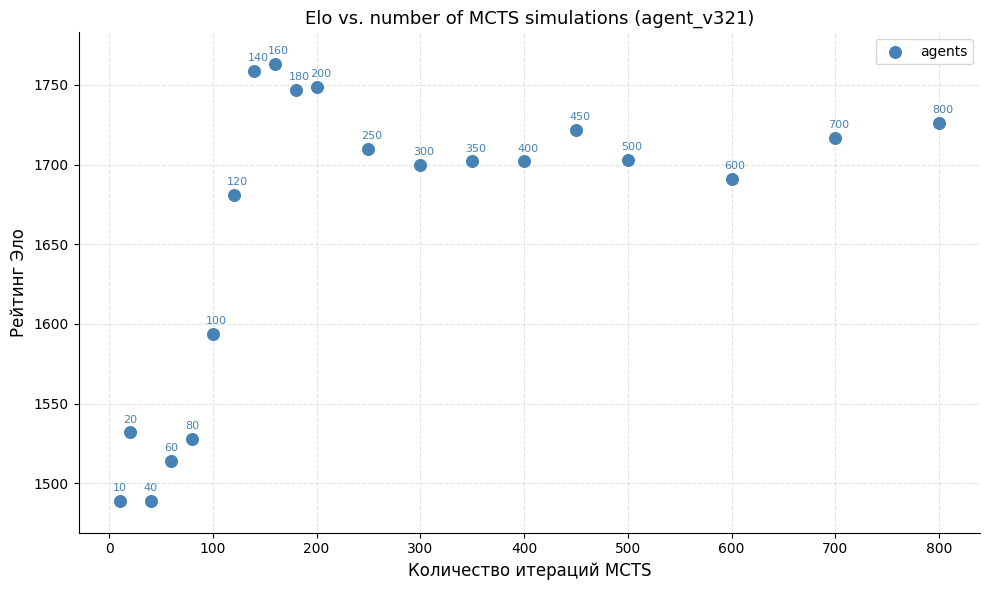

In [28]:
import matplotlib.pyplot as plt
import numpy as np

def plot_elo_vs_simulations(
    data=None,
    figsize=(10, 6),
    title="Elo vs. number of MCTS simulations (agent_v321)",
    fit_log=False,
):
    """
    data: list of (simulations, elo) tuples.
          По умолчанию подставлены данные из твоей таблицы.
    fit_log: если True — рисует логарифмическую кривую тренда.
    """

    if data is None:
        data = [
            (10,  -172),
            (20,  -129),
            (40,  -172),
            (60,  -147),
            (80,  -133),
            (100,  -67),
            (120,   20),
            (140,   98),
            (160,  102),
            (180,   86),
            (200,   88),
            (250,   49),
            (300,   39),
            (350,   41),
            (400,   41),
            (450,   61),
            (500,   42),
            (600,   30),
            (700,   56),
            (800,   65),
        ]
    delta = 1749 - 88
    n_data = []
    for i in data:
        b, r = i
        n_data.append((b, r + delta))
    data = n_data
        
    sims = np.array([d[0] for d in data])
    elos = np.array([d[1] for d in data])

    fig, ax = plt.subplots(figsize=figsize)

    ax.scatter(sims, elos, color="steelblue", s=70, zorder=4, label="agents")

    # Подписи точек
    for x, y in zip(sims, elos):
        ax.annotate(
            str(x),
            (x, y),
            textcoords="offset points",
            xytext=(-5, 7),
            fontsize=8,
            color="steelblue",
        )

    # Логарифмический тренд
    if fit_log:
        # fit: elo = a * log(sims) + b
        log_sims = np.log(sims)
        coeffs = np.polyfit(log_sims, elos, 1)   # [a, b]
        a, b = coeffs

        x_fit = np.linspace(sims.min(), sims.max(), 500)
        y_fit = a * np.log(x_fit) + b

        ax.plot(
            x_fit, y_fit,
            color="tomato",
            linewidth=2,
            linestyle="--",
            label=f"log fit: {a:.1f}·ln(n) + {b:.1f}",
            zorder=3,
        )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle=":")

    ax.set_xlabel("Количество итераций MCTS", fontsize=12)
    ax.set_ylabel("Рейтинг Эло", fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.35)

    ax.set_ylim(elos.min() - 20, elos.max() + 20)
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

    if fit_log:
        print(f"\nЛог. тренд: Elo ≈ {a:.2f} · ln(simulations) + {b:.2f}")
        print(f"Коэффициент a={a:.2f}: каждое удвоение симуляций даёт ≈ {a*np.log(2):.1f} Elo")


# Запуск:
plot_elo_vs_simulations()